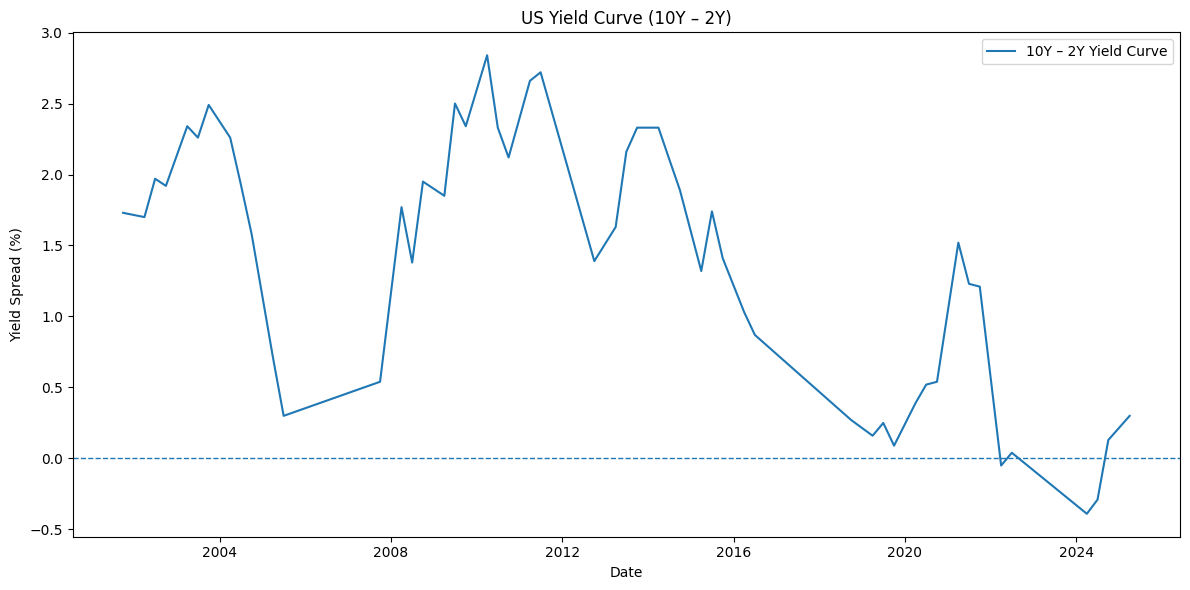

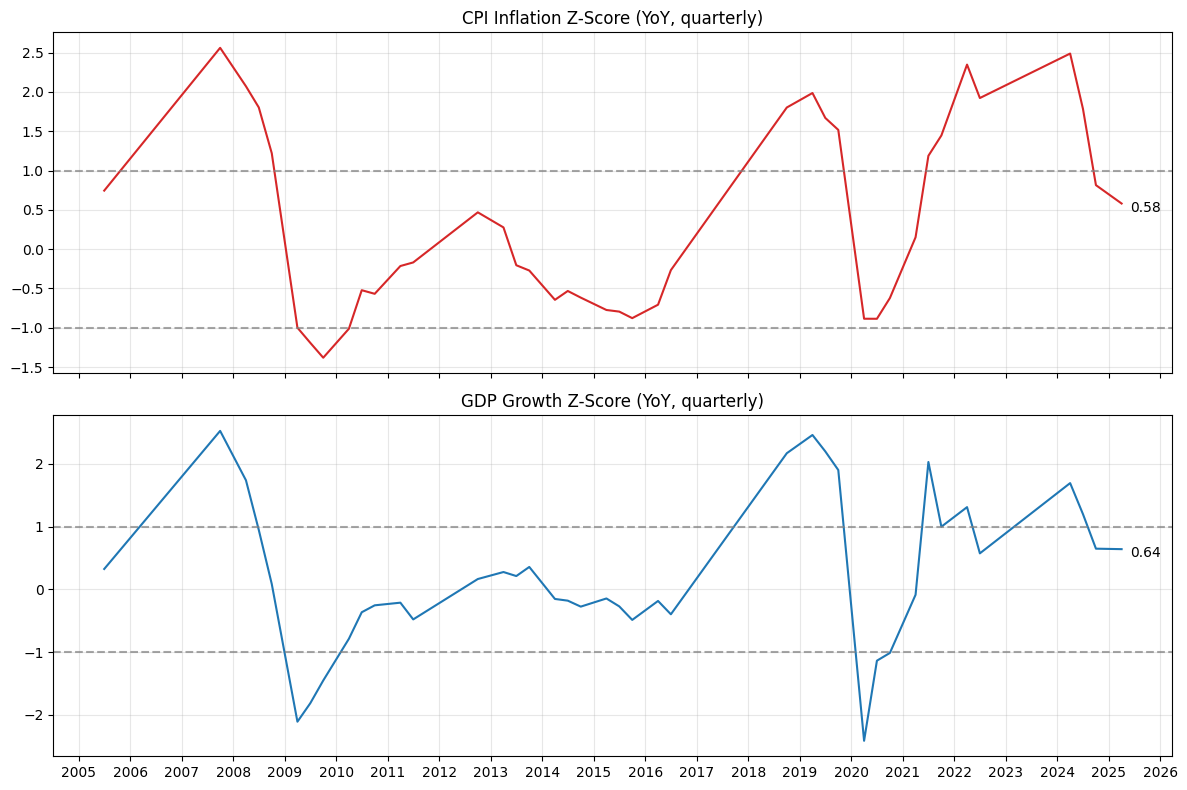

         DATE  YieldCurve  YieldCurveScore YieldCurveRegime    CPI_YoY  \
42 2020-10-01        0.54                0             Flat   1.765819   
43 2021-04-01        1.52                1            Steep   3.682604   
44 2021-07-01        1.23                1            Steep   6.223050   
45 2021-10-01        1.21                1            Steep   7.035363   
46 2022-04-01       -0.05               -1         Inverted  10.857064   
47 2022-07-01        0.04                0             Flat  10.619784   
48 2024-04-01       -0.39               -1         Inverted  15.094222   
49 2024-07-01       -0.29               -1         Inverted  13.393942   
50 2024-10-01        0.13                0             Flat   9.349856   
51 2025-04-01        0.30                0             Flat   8.605479   

       CPI_z  CPI_score    GDP_YoY     GDP_z  GDP_score  
42 -0.622140          0   1.703670 -1.013235         -1  
43  0.150921          0   6.805627 -0.086199          0  
44  1.18720

In [ ]:
# Yield Curve Plot and Macro Scoring (cleaned and fixed)

import pandas as pd
import builtins
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


type = input("Enter your investment type: ")


# Load and prepare data
df = pd.read_csv("macro_data.csv")
df['DATE'] = pd.to_datetime(df['DATE'])
df = df.sort_values('DATE').reset_index(drop=True)

# Ensure yield columns have no gaps
if 'Treasury10Y' in df.columns and 'Treasury2Y' in df.columns:
    df[['Treasury10Y', 'Treasury2Y']] = df[['Treasury10Y', 'Treasury2Y']].ffill()
    df['YieldCurve'] = df['Treasury10Y'] - df['Treasury2Y']

# Plot Yield Curve
plt.figure(figsize=(12, 6))
plt.plot(df['DATE'], df['YieldCurve'], label='10Y – 2Y Yield Curve')
plt.axhline(0, linestyle='--', linewidth=1)
plt.xlabel('Date')
plt.ylabel('Yield Spread (%)')
plt.title('US Yield Curve (10Y – 2Y)')
plt.legend()
plt.tight_layout()
plt.show()

# Scoring for Yield Curve

def yield_curve_score(spread):
    if pd.isna(spread):
        return 0
    if spread <= -0.5:
        return -2
    elif spread < 0:
        return -1
    elif spread < 1:
        return 0
    elif spread < 2:
        return 1
    else:
        return 2


def yield_curve_regime(spread):
    if pd.isna(spread):
        return 'Unknown'
    if spread <= -0.5:
        return 'Deep Inversion'
    elif spread < 0:
        return 'Inverted'
    elif spread < 1:
        return 'Flat'
    else:
        return 'Steep'

if 'YieldCurve' in df.columns:
    df['YieldCurveScore'] = df['YieldCurve'].apply(yield_curve_score)
    df['YieldCurveRegime'] = df['YieldCurve'].apply(yield_curve_regime)
else:
    df['YieldCurveScore'] = 0
    df['YieldCurveRegime'] = 'Unknown'


# --- CPI & GDP: Fixes for quarterly data ---
# The dataset is quarterly, so YoY = pct_change(4) (not 12). Also use window=20 (~5 years) for quarterly data.
periods = 4           # quarters for YoY
window = 20           # ~5 years in quarters
min_periods = 8       # minimum points to calculate rolling stats (helps avoid spurious std=0 early on)

# CPI YoY
if 'CPI' in df.columns:
    df['CPI_YoY'] = df['CPI'].pct_change(periods) * 100
    df['CPI_YoY_mean'] = df['CPI_YoY'].rolling(window=window, min_periods=min_periods).mean()
    df['CPI_YoY_std'] = df['CPI_YoY'].rolling(window=window, min_periods=min_periods).std()
    df['CPI_z'] = (df['CPI_YoY'] - df['CPI_YoY_mean']) / df['CPI_YoY_std']
else:
    df['CPI_YoY'] = df['CPI_z'] = df['CPI_YoY_mean'] = df['CPI_YoY_std'] = pd.NA


def inflation_score(z):
    if pd.isna(z):
        return 0
    elif z > 1:
        return -1   # overheating
    elif z < -1:
        return 1    # disinflationary tailwind
    else:
        return 0

if 'CPI_z' in df.columns:
    df['CPI_score'] = df['CPI_z'].apply(inflation_score)
else:
    df['CPI_score'] = 0

# GDP YoY
if 'GDP' in df.columns:
    df['GDP_YoY'] = df['GDP'].pct_change(periods) * 100
    df['GDP_YoY_mean'] = df['GDP_YoY'].rolling(window=window, min_periods=min_periods).mean()
    df['GDP_YoY_std'] = df['GDP_YoY'].rolling(window=window, min_periods=min_periods).std()
    df['GDP_z'] = (df['GDP_YoY'] - df['GDP_YoY_mean']) / df['GDP_YoY_std']
else:
    df['GDP_YoY'] = df['GDP_z'] = df['GDP_YoY_mean'] = df['GDP_YoY_std'] = pd.NA


def growth_score(z):
    if pd.isna(z):
        return 0
    elif z > 1:
        return 1     # strong expansion
    elif z < -1:
        return -1    # contraction risk
    else:
        return 0

if 'GDP_z' in df.columns:
    df['GDP_score'] = df['GDP_z'].apply(growth_score)
else:
    df['GDP_score'] = 0

# Helpful checks
if df['CPI_YoY'].isna().all():
    print('Warning: CPI YoY is all NaN — check data frequency or missing CPI values')
if df['GDP_YoY'].isna().all():
    print('Warning: GDP YoY is all NaN — check data frequency or missing GDP values')

# --- Improved plots for CPI and GDP z-scores ---
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 8), sharex=True)

# CPI
axes[0].plot(df['DATE'], df['CPI_z'], label='CPI Z-Score', color='tab:red')
axes[0].axhline(1, linestyle='--', color='gray', alpha=0.7)
axes[0].axhline(-1, linestyle='--', color='gray', alpha=0.7)
axes[0].set_title('CPI Inflation Z-Score (YoY, quarterly)')
axes[0].grid(True, alpha=0.3)

# annotate last non-NaN
if df['CPI_z'].dropna().shape[0] > 0:
    last_idx = df['CPI_z'].last_valid_index()
    axes[0].annotate(f"{df.loc[last_idx,'CPI_z']:.2f}", xy=(df.loc[last_idx,'DATE'], df.loc[last_idx,'CPI_z']),
                     xytext=(6, -6), textcoords='offset points')

# GDP
axes[1].plot(df['DATE'], df['GDP_z'], label='GDP Z-Score', color='tab:blue')
axes[1].axhline(1, linestyle='--', color='gray', alpha=0.7)
axes[1].axhline(-1, linestyle='--', color='gray', alpha=0.7)
axes[1].set_title('GDP Growth Z-Score (YoY, quarterly)')
axes[1].grid(True, alpha=0.3)

if df['GDP_z'].dropna().shape[0] > 0:
    last_idx = df['GDP_z'].last_valid_index()
    axes[1].annotate(f"{df.loc[last_idx,'GDP_z']:.2f}", xy=(df.loc[last_idx,'DATE'], df.loc[last_idx,'GDP_z']),
                     xytext=(6, -6), textcoords='offset points')

axes[1].xaxis.set_major_locator(mdates.YearLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

# Print last rows and combined score
# Restore built-in print in case it was shadowed (fix TypeError: 'str' object is not callable)
print = builtins.print

print(df[['DATE', 'YieldCurve', 'YieldCurveScore', 'YieldCurveRegime',
          'CPI_YoY', 'CPI_z', 'CPI_score', 'GDP_YoY', 'GDP_z', 'GDP_score']].tail(10))

# Combined score
df['CombinedScore'] = df[['YieldCurveScore', 'CPI_score', 'GDP_score']].sum(axis=1)
print('Latest combined score:', df['CombinedScore'].iloc[-1])

score_current = df.loc[df['DATE'] == '2025-04-01', 'CombinedScore'].values[0]

print(score_current)
